<a href="https://colab.research.google.com/github/PandeyChhaya/6CS012-AI-ML/blob/main/2522725_ChhayaPandey_code_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 – Part III: Language Task
## Sentiment Analysis with RNN, LSTM and Word2Vec – Financial Phrase Dataset

Installing Dependencies


In [2]:
!pip install -q wordcloud gradio
!pip install -q gensim
!pip install -q nltk

Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Loading Dataset


In [4]:
from google.colab import files
uploaded = files.upload()

Saving 3. Financial Phrase Dataset-20260508T153047Z-3-001.zip to 3. Financial Phrase Dataset-20260508T153047Z-3-001 (1).zip


In [6]:
import zipfile
import os

zip_name = '3. Financial Phrase Dataset-20260508T153047Z-3-001 (1).zip'

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/')
    print('Files extracted:', z.namelist())

Files extracted: ['3. Financial Phrase Dataset/financial_phrase.csv', '3. Financial Phrase Dataset/3. Description Financial Phrase Dataset.txt']


In [7]:
df = pd.read_csv('/content/3. Financial Phrase Dataset/financial_phrase.csv')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nLabel distribution:')
print(df['label'].value_counts())

Shape: (2264, 2)

First 5 rows:


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive



Label distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


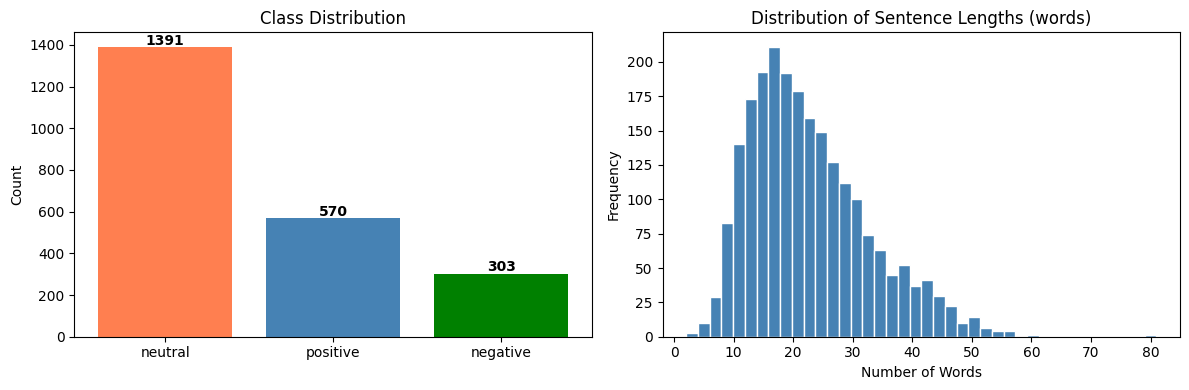

Average sentence length: 22.4 words
Max sentence length: 81 words
95th percentile: 42 words


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
ax1.bar(counts.index, counts.values, color=['coral', 'steelblue', 'green'])
ax1.set_title('Class Distribution')
ax1.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')

df['text_length'] = df['text'].apply(lambda x: len(x.split()))
ax2.hist(df['text_length'], bins=40, color='steelblue', edgecolor='white')
ax2.set_title('Distribution of Sentence Lengths (words)')
ax2.set_xlabel('Number of Words')
ax2.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Average sentence length: {df["text_length"].mean():.1f} words')
print(f'Max sentence length: {df["text_length"].max()} words')
print(f'95th percentile: {np.percentile(df["text_length"], 95):.0f} words')

Text Preprocessing

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace("n't", ' not').replace("'re", ' are').replace("'s", ' is')
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

print('Original:', df['text'].iloc[0])
print('Cleaned: ', df['cleaned_text'].iloc[0])

Original: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
Cleaned:  according gran company plan move production russia although company growing


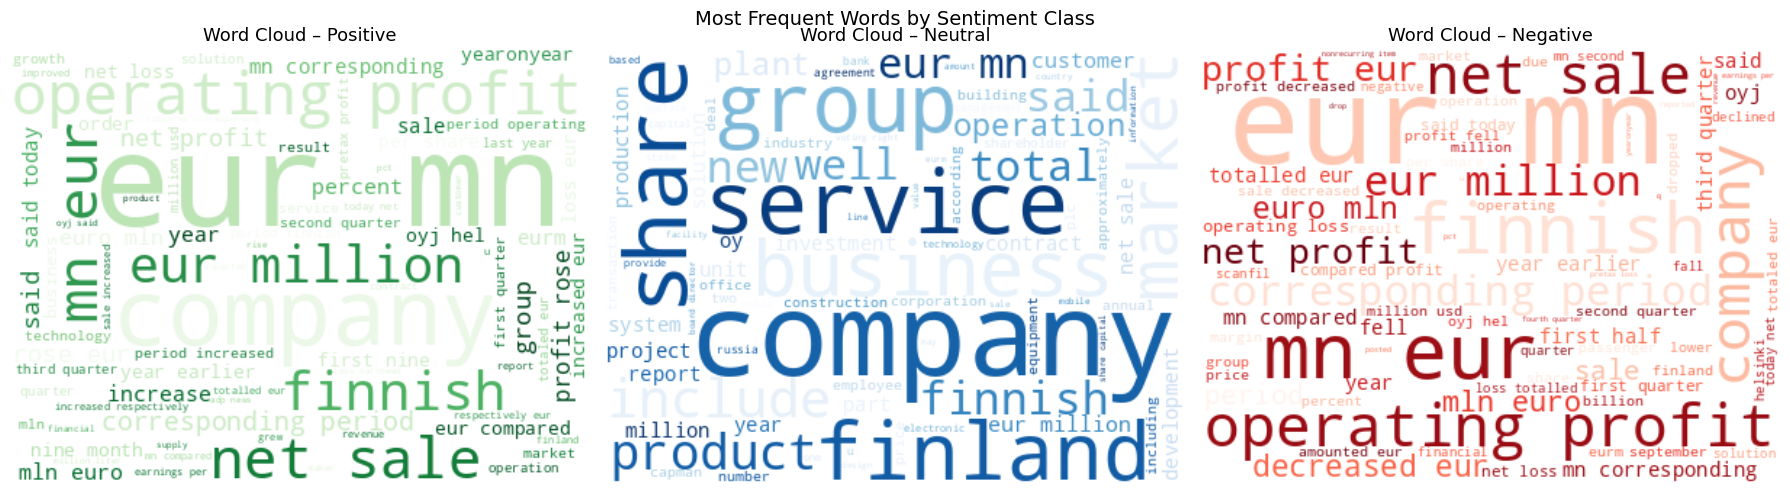

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['positive', 'neutral', 'negative']
colors = ['Greens', 'Blues', 'Reds']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df[df['label'] == label]['cleaned_text'])
    wc = WordCloud(width=400, height=300, background_color='white', colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud – {label.capitalize()}', fontsize=13)
    ax.axis('off')

plt.suptitle('Most Frequent Words by Sentiment Class', fontsize=14)
plt.tight_layout()
plt.show()

Tokenization, Encoding and Padding

In [12]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

NUM_CLASSES = len(le.classes_)

X = df['cleaned_text'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)}')
print(f'Test size:  {len(X_test)}')

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train size: 1811
Test size:  453


In [13]:
MAX_WORDS = 10000
MAX_LEN   = int(np.percentile([len(t.split()) for t in X_train], 95))
print(f'Max sequence length (95th percentile): {MAX_LEN}')

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

vocab_size  = min(MAX_WORDS, len(tokenizer.word_index) + 1)
word_index  = tokenizer.word_index
print(f'Vocabulary size: {vocab_size}')

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Train padded shape: {X_train_pad.shape}')
print(f'Test  padded shape: {X_test_pad.shape}')

Max sequence length (95th percentile): 22
Vocabulary size: 4417
Train padded shape: (1811, 22)
Test  padded shape: (453, 22)


In [14]:
y_train_cat = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = keras.utils.to_categorical(y_test,  NUM_CLASSES)
print('y_train_cat shape:', y_train_cat.shape)

y_train_cat shape: (1811, 3)


Model 1 – Simple RNN with Trainable Embedding

In [15]:
EMBEDDING_DIM = 64

rnn_model = models.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    layers.SimpleRNN(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='SimpleRNN_Model')

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
callbacks = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

rnn_history = rnn_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.6624 - loss: 0.8006 - val_accuracy: 0.7802 - val_loss: 0.5800
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8029 - loss: 0.4662 - val_accuracy: 0.7857 - val_loss: 0.5335
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8478 - loss: 0.3237 - val_accuracy: 0.7637 - val_loss: 0.5708
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8883 - loss: 0.2555 - val_accuracy: 0.8022 - val_loss: 0.5267
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9521 - loss: 0.1434 - val_accuracy: 0.8132 - val_loss: 0.5254
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9613 - loss: 0.1080 - val_accuracy: 0.7637 - val_loss: 0.7407
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9693 - loss: 0.1077 - val_accuracy: 0.8022 - val_loss: 0.6582
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9742 - loss: 0.0872 - val_accuracy: 0.8132 - val_loss

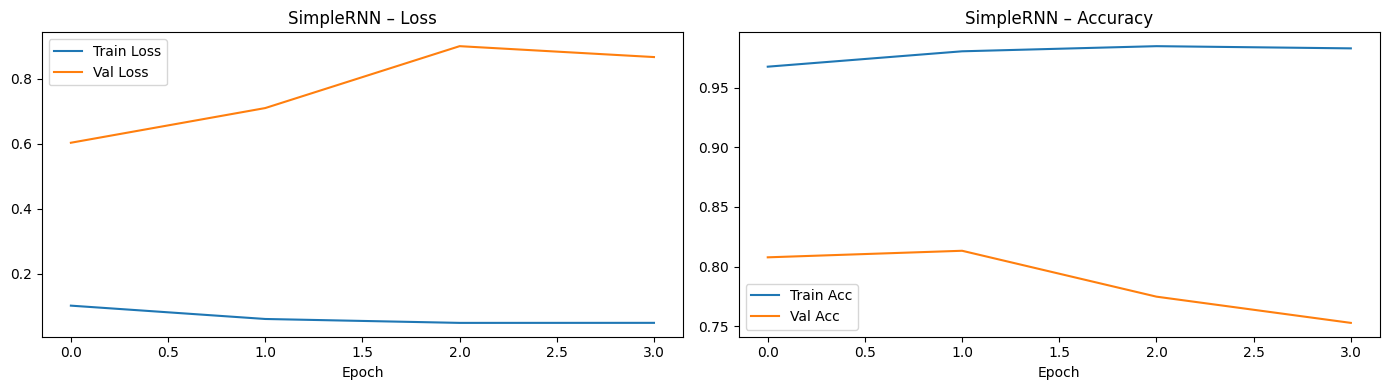

In [18]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['loss'],     label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'{title} – Loss')
    ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.plot(history.history['accuracy'],     label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title(f'{title} – Accuracy')
    ax2.set_xlabel('Epoch'); ax2.legend()
    plt.tight_layout(); plt.show()

plot_history(rnn_history, 'SimpleRNN')


SimpleRNN – Test Loss: 0.8848 | Test Accuracy: 0.7594

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.51      0.55        61
     neutral       0.93      0.81      0.86       278
    positive       0.55      0.77      0.64       114

    accuracy                           0.76       453
   macro avg       0.70      0.70      0.69       453
weighted avg       0.79      0.76      0.77       453



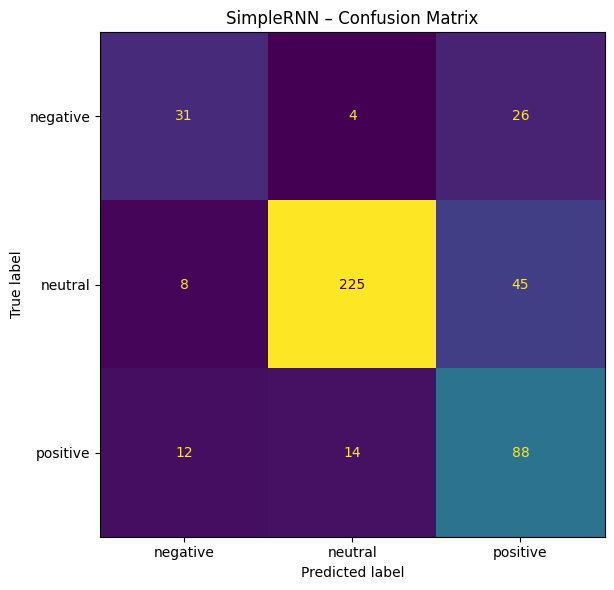

In [19]:
def evaluate_model(model, X_test, y_test_cat, y_test, model_name, label_names):
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f'\n{model_name} – Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}')
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=label_names))
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} – Confusion Matrix')
    plt.tight_layout(); plt.show()
    return acc, y_pred

label_names = list(le.classes_)
rnn_acc, rnn_preds = evaluate_model(rnn_model, X_test_pad, y_test_cat, y_test, 'SimpleRNN', label_names)

Step 7: Model 2 – LSTM with Trainable Embedding

In [20]:
lstm_model = models.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Model')

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.6126 - loss: 0.9061 - val_accuracy: 0.7802 - val_loss: 0.6127
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7655 - loss: 0.5727 - val_accuracy: 0.7912 - val_loss: 0.5429
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8220 - loss: 0.4167 - val_accuracy: 0.8077 - val_loss: 0.5019
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8447 - loss: 0.3402 - val_accuracy: 0.7857 - val_loss: 0.6116
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8496 - loss: 0.3101 - val_accuracy: 0.7912 - val_loss: 0.5561
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8502 - loss: 0.2981 - val_accuracy: 0.7802 - val_loss: 0.6551


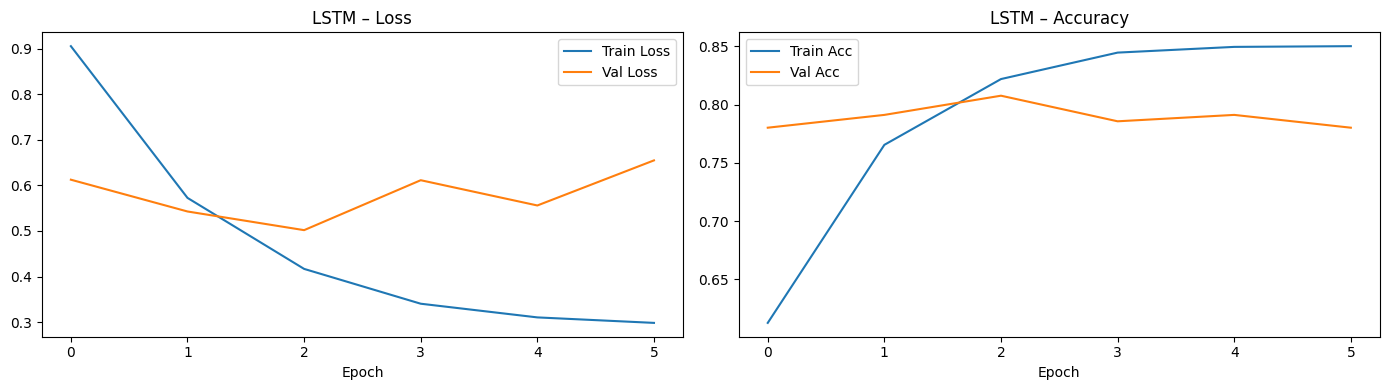


LSTM – Test Loss: 0.5217 | Test Accuracy: 0.7770

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.91      0.94      0.92       278
    positive       0.55      0.81      0.66       114

    accuracy                           0.78       453
   macro avg       0.49      0.58      0.53       453
weighted avg       0.70      0.78      0.73       453



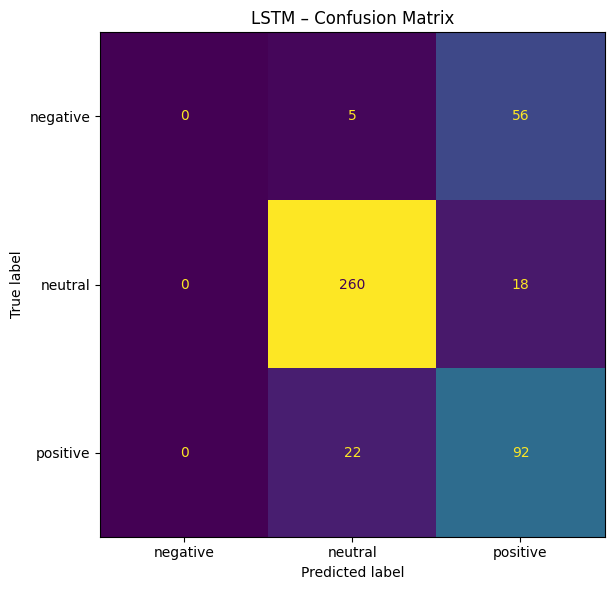

In [21]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)
plot_history(lstm_history, 'LSTM')
lstm_acc, lstm_preds = evaluate_model(lstm_model, X_test_pad, y_test_cat, y_test, 'LSTM', label_names)

Step 8: Model 3 – LSTM with Pretrained Word2Vec (GloVe) Embeddings

In [22]:
import gensim.downloader as api
print('Downloading GloVe embeddings... this may take a few minutes')
embedding_model = api.load('glove-wiki-gigaword-50')
print('Done!')

[==================================================] 100.0% 66.0/66.0MB downloaded
Done!


In [23]:
GLOVE_DIM = 50
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))
found = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

print(f'Words found in GloVe: {found} / {min(vocab_size, len(word_index))}')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Words found in GloVe: 3803 / 4416
Embedding matrix shape: (4417, 50)


In [24]:
lstm_w2v = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Word2Vec')

lstm_w2v.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_w2v.summary()

Model: "LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       220,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,850 (862.70 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 220,850 (862.70 KB)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6519 - loss: 0.8128 - val_accuracy: 0.7582 - val_loss: 0.5952
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7471 - loss: 0.6159 - val_accuracy: 0.7637 - val_loss: 0.5573
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7569 - loss: 0.5772 - val_accuracy: 0.7418 - val_loss: 0.6001


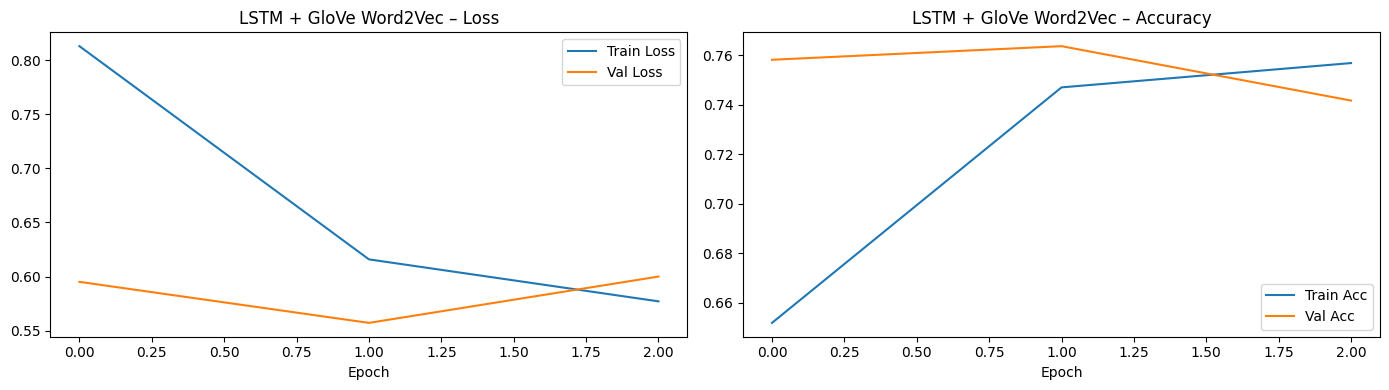


LSTM + Word2Vec – Test Loss: 0.6305 | Test Accuracy: 0.7373

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.82      0.95      0.88       278
    positive       0.54      0.61      0.57       114

    accuracy                           0.74       453
   macro avg       0.45      0.52      0.48       453
weighted avg       0.64      0.74      0.68       453



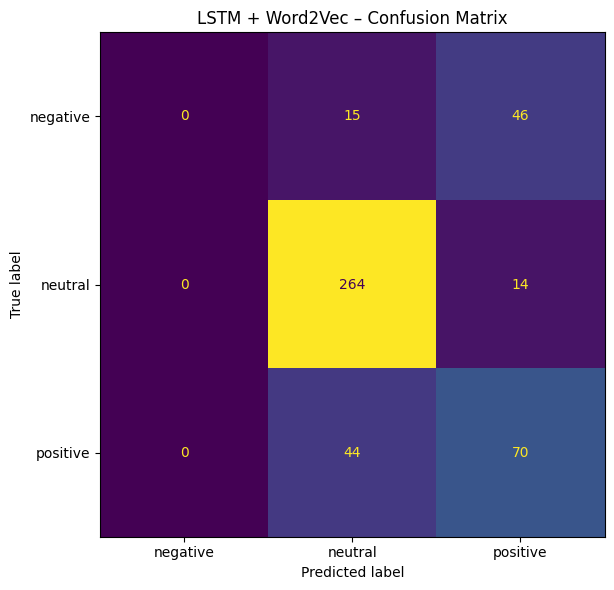

In [25]:
w2v_history = lstm_w2v.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)
plot_history(w2v_history, 'LSTM + GloVe Word2Vec')
w2v_acc, w2v_preds = evaluate_model(lstm_w2v, X_test_pad, y_test_cat, y_test, 'LSTM + Word2Vec', label_names)

Model Comparison

          Model  Test Accuracy
      SimpleRNN       0.759382
           LSTM       0.777042
LSTM + Word2Vec       0.737307


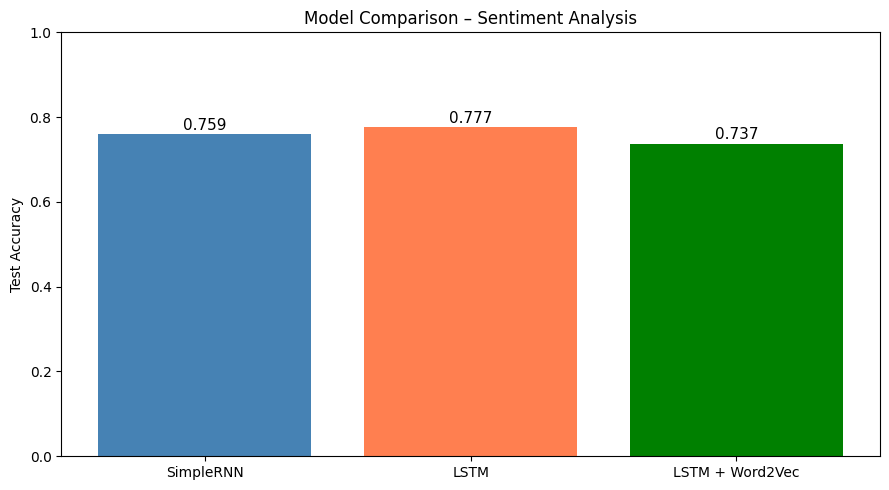

In [26]:
results = pd.DataFrame({
    'Model':        ['SimpleRNN', 'LSTM', 'LSTM + Word2Vec'],
    'Test Accuracy': [rnn_acc,    lstm_acc, w2v_acc]
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(results['Model'], results['Test Accuracy'], color=['steelblue', 'coral', 'green'])
ax.set_ylim(0, 1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison – Sentiment Analysis')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

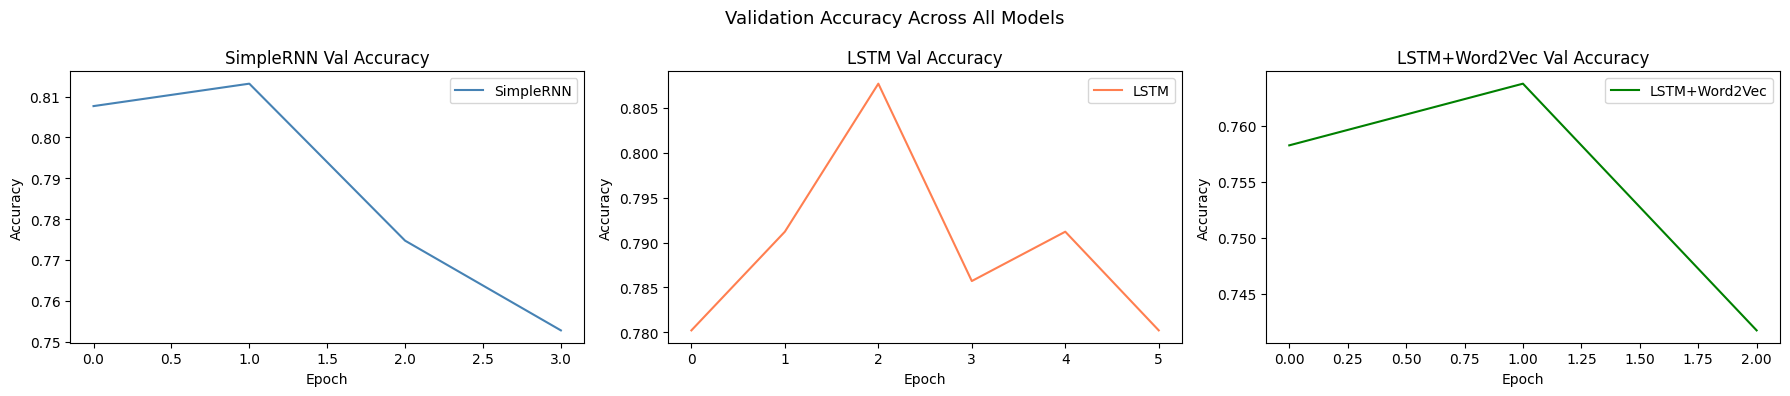

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
model_names = ['SimpleRNN', 'LSTM', 'LSTM+Word2Vec']
histories   = [rnn_history, lstm_history, w2v_history]
colors      = [('steelblue', 'orange'), ('coral', 'red'), ('green', 'lime')]

for ax, hist, name, (c1, c2) in zip(axes, histories, model_names, colors):
    ax.plot(hist.history['val_accuracy'], color=c1, label=name)
    ax.set_title(f'{name} Val Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.suptitle('Validation Accuracy Across All Models', fontsize=13)
plt.tight_layout()
plt.show()

Error Analysis

In [28]:
print('=== Error Analysis – LSTM + Word2Vec (Best Model) ===\n')

wrong_idx = np.where(w2v_preds != y_test)[0]
print(f'Total misclassified: {len(wrong_idx)} out of {len(y_test)}')

print('\n--- Sample Misclassified Examples ---')
for i in wrong_idx[:3]:
    print(f'\nText (cleaned): {X_test[i]}')
    print(f'True label    : {label_names[y_test[i]]}')
    print(f'Predicted     : {label_names[w2v_preds[i]]}')

=== Error Analysis – LSTM + Word2Vec (Best Model) ===

Total misclassified: 119 out of 453

--- Sample Misclassified Examples ---

Text (cleaned): september alone market declined percent yearonyear million liter
True label    : negative
Predicted     : positive

Text (cleaned): goodwill intangible asset account mln euro mln purchase price pct payable aspo share
True label    : neutral
Predicted     : positive

Text (cleaned): major order india comptel corporation received significant longterm order mediation provisioning solution used leading operator india
True label    : positive
Predicted     : neutral


Gradio GUI for Real-Time Prediction

In [29]:
import gradio as gr

def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = lstm_w2v.predict(padded, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = label_names[pred_idx]
    confidence = probs[pred_idx]
    result = f'Sentiment: {pred_label.upper()}\nConfidence: {confidence:.2%}\n\n'
    for i, (label, prob) in enumerate(zip(label_names, probs)):
        bar = '█' * int(prob * 20)
        result += f'{label:10s}: {bar} {prob:.2%}\n'
    return result

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder='Enter a financial news sentence...', label='Input Text'),
    outputs=gr.Textbox(label='Prediction'),
    title='Financial Sentiment Analyzer',
    description='Predicts whether a financial news sentence is Positive, Neutral, or Negative using LSTM + Word2Vec.',
    examples=[
        ['The company reported record profits this quarter, exceeding all analyst expectations.'],
        ['The firm announced it would lay off 500 employees due to declining revenues.'],
        ['The board of directors approved the annual budget for the upcoming fiscal year.']
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2ae3290ceb452da808.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
